In [1]:
# ================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ================================

# Biblioteca principal para manipulação de dados (DataFrames)
import pandas as pd

# Biblioteca para normalização dos dados (Etapa 5)
from sklearn.preprocessing import MinMaxScaler

# Biblioteca para criação de gráficos (análise visual)
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
# ================================
# LEITURA E LIMPEZA DOS DADOS DE CRIMES
# ================================

# Lista de arquivos CSV (anos diferentes)
arquivos = [
    'dados_secretaria/dados2021.csv',
    'dados_secretaria/dados2022.csv',
    'dados_secretaria/dados2023.csv',
    'dados_secretaria/dados2024.csv',
    'dados_secretaria/dados2025.csv',
    'dados_secretaria/dados2026.csv',
]

# Lista para armazenar os pedaços (chunks) dos arquivos
dfs = []

# Leitura em partes para economizar memória
for arq in arquivos:
    for chunk in pd.read_csv(arq, sep=';', encoding='latin1', chunksize=50000):

        # Padroniza nomes das colunas (minúsculo e sem espaços)
        chunk.columns = chunk.columns.str.lower().str.strip()

        # Remove colunas desnecessárias geradas automaticamente
        chunk = chunk.loc[:, ~chunk.columns.str.contains('^unnamed')]
        chunk = chunk.loc[:, chunk.columns != '...']

        # Remove linhas sem data
        chunk = chunk.dropna(subset=['data fato'])

        # Converte a coluna de data para formato datetime
        chunk['data fato'] = pd.to_datetime(chunk['data fato'], errors='coerce', dayfirst=True)

        # Remove datas inválidas
        chunk = chunk.dropna(subset=['data fato'])

        # Padroniza colunas de texto (minúsculo e sem espaços extras)
        for col in ['tipo fato', 'grupo fato', 'municipio fato', 'bairro', 'local fato', 'tipo enquadramento']:
            if col in chunk.columns:
                chunk[col] = chunk[col].astype(str).str.lower().str.strip()

        # Adiciona o chunk tratado à lista
        dfs.append(chunk)

# Junta todos os dados em um único DataFrame e remove duplicatas
df_crimes = pd.concat(dfs, ignore_index=True).drop_duplicates()

C:\Users\sinpl\AppData\Local\Temp\ipykernel_24136\3479958504.py:20: DtypeWarning: Columns (0: Unnamed: 23, 1: Unnamed: 24, 2: Unnamed: 26, 3: Unnamed: 27, 4: Unnamed: 29, 5: Unnamed: 30, 6: Unnamed: 32, 7: Unnamed: 33, 8: Unnamed: 35, 9: Unnamed: 36, 10: Unnamed: 38, 11: Unnamed: 39, 12: Unnamed: 41, 13: Unnamed: 42, 14: Unnamed: 44, 15: Unnamed: 45, 16: Unnamed: 47, 17: Unnamed: 48, 18: Unnamed: 50, 19: Unnamed: 51, 20: Unnamed: 53, 21: Unnamed: 54, 22: Unnamed: 56, 23: Unnamed: 57, 24: Unnamed: 59, 25: Unnamed: 60, 26: Unnamed: 62, 27: Unnamed: 63, 28: Unnamed: 65, 29: Unnamed: 66, 30: Unnamed: 68, 31: Unnamed: 69, 32: Unnamed: 71, 33: Unnamed: 72, 34: Unnamed: 74, 35: Unnamed: 75, 36: Unnamed: 77, 37: Unnamed: 78, 38: Unnamed: 80, 39: Unnamed: 81, 40: Unnamed: 83, 41: Unnamed: 84, 42: Unnamed: 86, 43: Unnamed: 87, 44: Unnamed: 89, 45: Unnamed: 90, 46: Unnamed: 92, 47: Unnamed: 93, 48: Unnamed: 95, 49: Unnamed: 96, 50: Unnamed: 98, 51: Unnamed: 99, 52: Unnamed: 101, 53: Unnamed: 102,

In [3]:
# ================================
# FILTRO DOS DADOS PARA PASSO FUNDO
# ================================

# Seleciona apenas registros da cidade desejada
df_pf = df_crimes[df_crimes['municipio fato'] == 'passo fundo'].copy()

# Cria coluna padrão de cidade (necessária para o merge)
df_pf['cidade'] = 'passo fundo'

In [4]:
# ================================
# AGREGAÇÃO DOS DADOS POR DIA
# ================================

# Agrupa os dados por data e cidade
df_diario = (
    df_pf.groupby(['data fato', 'cidade'], as_index=False)
    .agg(
        # Total de ocorrências no dia
        ocorrencias=('data fato', 'count'),

        # Total de vítimas no dia
        vitimas_total=('quantidade vítimas', 'sum'),

        # Média de idade das vítimas
        idade_media_vitima=('idade vítima', 'mean'),

        # Contagem de tipos de crime
        furtos=('tipo enquadramento', lambda x: x.str.contains('furto', na=False).sum()),
        roubos=('tipo enquadramento', lambda x: x.str.contains('roubo', na=False).sum()),
        homicidios=('tipo enquadramento', lambda x: x.str.contains('homic', na=False).sum())
    )
)

In [5]:
# ================================
# LEITURA DOS DADOS METEOROLÓGICOS
# ================================

# Lê o arquivo ignorando linhas iniciais desnecessárias
df_meteo = pd.read_csv(
    'dados_tempo21-25/pfdados.csv',
    sep=';',
    encoding='latin1',
    skiprows=10
)

# Padroniza nomes das colunas (remove acentos e espaços)
df_meteo.columns = (
    df_meteo.columns
    .str.lower()
    .str.strip()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

# Remove colunas inúteis
df_meteo = df_meteo.loc[:, ~df_meteo.columns.str.contains('^unnamed')]
if '' in df_meteo.columns:
    df_meteo = df_meteo.drop(columns=[''])

In [6]:
# ================================
# PADRONIZAÇÃO DOS NOMES DAS COLUNAS
# ================================

# Cria um mapeamento automático para nomes padronizados
mapa = {}

for col in df_meteo.columns:
    if 'data' in col:
        mapa[col] = 'data fato'
    elif 'precipitacao' in col:
        mapa[col] = 'precipitacao'
    elif 'temperatura maxima' in col:
        mapa[col] = 'temperatura_maxima'
    elif 'temperatura minima' in col:
        mapa[col] = 'temperatura_minima'
    elif 'umidade relativa' in col:
        mapa[col] = 'umidade_relativa'
    elif 'vento' in col and 'velocidade' in col:
        mapa[col] = 'vento_velocidade'

# Renomeia as colunas
df_meteo = df_meteo.rename(columns=mapa)

In [7]:
# ================================
# TRATAMENTO DOS DADOS METEOROLÓGICOS
# ================================

# Converte a data
df_meteo['data fato'] = pd.to_datetime(df_meteo['data fato'], errors='coerce')

# Converte colunas numéricas (corrige vírgula decimal)
for col in ['precipitacao', 'temperatura_maxima', 'temperatura_minima', 'umidade_relativa', 'vento_velocidade']:
    if col in df_meteo.columns:
        df_meteo[col] = (
            df_meteo[col]
            .astype(str)
            .str.replace(',', '.', regex=False)
            .str.strip()
        )
        df_meteo[col] = pd.to_numeric(df_meteo[col], errors='coerce')

# Cria temperatura média
if 'temperatura_maxima' in df_meteo.columns and 'temperatura_minima' in df_meteo.columns:
    df_meteo['temperatura_media'] = (
        df_meteo['temperatura_maxima'] + df_meteo['temperatura_minima']
    ) / 2

# Adiciona cidade
df_meteo['cidade'] = 'passo fundo'

# Remove duplicatas
df_meteo = df_meteo.drop_duplicates(subset=['data fato', 'cidade'])

In [8]:
# ================================
# INTEGRAÇÃO DOS DADOS (CRIMES + CLIMA)
# ================================

# Junta os dois datasets pela data e cidade
df_integrado = pd.merge(
    df_diario,
    df_meteo[['data fato', 'cidade', 'precipitacao', 'temperatura_maxima',
              'temperatura_minima', 'temperatura_media',
              'umidade_relativa', 'vento_velocidade']],
    on=['data fato', 'cidade'],
    how='left'
)

In [9]:
# ================================
# TRATAMENTO DE DADOS FALTANTES
# ================================

# Ordena por data (necessário para interpolação)
df_integrado = df_integrado.sort_values('data fato')

colunas_meteo = [
    'precipitacao', 'temperatura_maxima', 'temperatura_minima',
    'temperatura_media', 'umidade_relativa', 'vento_velocidade'
]

# Preenche valores ausentes com interpolação
for col in colunas_meteo:
    if col in df_integrado.columns:
        df_integrado[col] = df_integrado[col].interpolate(limit_direction='both')

# Preenche possíveis valores restantes com a mediana
for col in colunas_meteo:
    if col in df_integrado.columns:
        df_integrado[col] = df_integrado[col].fillna(df_integrado[col].median())

In [10]:
# ================================
# PREPARAÇÃO PARA ETAPA 5
# ================================

# Cria cópia do dataset integrado
df = df_integrado.copy()

In [11]:
# ================================
# CRIAÇÃO DE NOVAS VARIÁVEIS
# ================================

# Extrai informações da data
df['dia_semana'] = df['data fato'].dt.day_name()
df['mes'] = df['data fato'].dt.month
df['ano'] = df['data fato'].dt.year

# Indica se é fim de semana (1 = sim, 0 = não)
df['fim_de_semana'] = df['data fato'].dt.dayofweek.isin([5, 6]).astype(int)

# Converte dia da semana para número
mapa_dia = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
    'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6
}

df['dia_semana_num'] = df['dia_semana'].map(mapa_dia)

In [12]:
# ================================
# DETECÇÃO DE OUTLIERS (IQR)
# ================================

colunas_numericas = df.select_dtypes(include='number').columns

for col in colunas_numericas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    # Limites inferior e superior
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr

    # Conta quantos outliers existem
    qtd = df[(df[col] < li) | (df[col] > ls)].shape[0]

    print(f"{col}: {qtd} outliers")

ocorrencias: 7 outliers
vitimas_total: 6 outliers
idade_media_vitima: 15 outliers
furtos: 12 outliers
roubos: 4 outliers
homicidios: 276 outliers
precipitacao: 206 outliers
temperatura_maxima: 17 outliers
temperatura_minima: 36 outliers
temperatura_media: 38 outliers
umidade_relativa: 13 outliers
vento_velocidade: 3 outliers
mes: 0 outliers
ano: 0 outliers
fim_de_semana: 0 outliers
dia_semana_num: 0 outliers


In [13]:
# ================================
# NORMALIZAÇÃO DOS DADOS
# ================================

# Inicializa o normalizador
scaler = MinMaxScaler()

# Seleciona colunas numéricas
colunas = df.select_dtypes(include='number').columns

# Aplica normalização (valores entre 0 e 1)
df[[col + '_norm' for col in colunas]] = scaler.fit_transform(df[colunas])

ocorrencias                1.000000
ocorrencias_norm           1.000000
vitimas_total              0.858997
vitimas_total_norm         0.858997
furtos_norm                0.450463
furtos                     0.450463
ano                        0.280429
ano_norm                   0.280429
temperatura_media_norm     0.252264
temperatura_media          0.252264
temperatura_maxima_norm    0.234168
temperatura_maxima         0.234168
temperatura_minima         0.233705
temperatura_minima_norm    0.233705
roubos                     0.070656
roubos_norm                0.070656
idade_media_vitima         0.067622
idade_media_vitima_norm    0.067622
homicidios_norm            0.039991
homicidios                 0.039991
precipitacao_norm         -0.004144
precipitacao              -0.004144
vento_velocidade_norm     -0.016953
vento_velocidade          -0.016953
mes_norm                  -0.036857
mes                       -0.036857
umidade_relativa          -0.055049
umidade_relativa_norm     -0

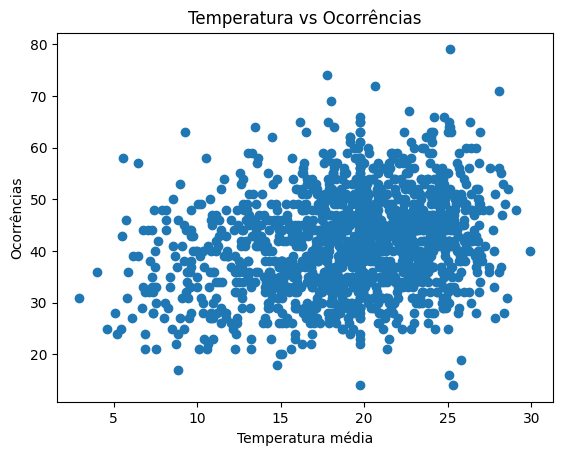

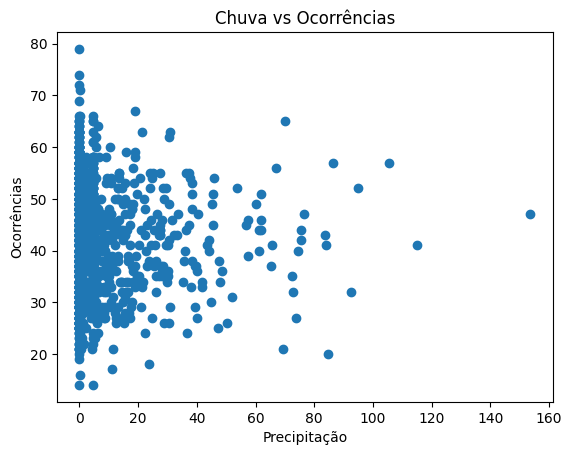

In [14]:
# ================================
# ANÁLISE E VISUALIZAÇÃO
# ================================

# Matriz de correlação
correlacao = df.corr(numeric_only=True)
print(correlacao['ocorrencias'].sort_values(ascending=False))

# Relação entre temperatura e crimes
plt.figure()
plt.scatter(df['temperatura_media'], df['ocorrencias'])
plt.title("Temperatura vs Ocorrências")
plt.xlabel("Temperatura média")
plt.ylabel("Ocorrências")
plt.show()

# Relação entre chuva e crimes
plt.figure()
plt.scatter(df['precipitacao'], df['ocorrencias'])
plt.title("Chuva vs Ocorrências")
plt.xlabel("Precipitação")
plt.ylabel("Ocorrências")
plt.show()